# Plasmadiagnostik mit Langmuir-Sonden

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.optimize import least_squares
from scipy.stats import linregress
import os

In [56]:
def linear_res(coeff, x, y):
    a, b = coeff
    return y - (a*x+b)

def linear(coeff, x):
    a, b = coeff
    return a*x+b

def derive(x, y, step=1):
    x, y = list(x), list(y)
    x_new, y_new, x_shifted = [], [], []
    for i, val in enumerate(x):
        if i%step == 0:
            x_new.append(val)
    for i, val in enumerate(y):
        if i % step == 0:
            y_new.append(val)
    x_new = np.array(x_new)
    y_new = np.array(y_new)
    der = np.insert(np.diff(y_new)/np.diff(x_new), 0, np.nan)
    width_list = []
    for i in range(len((x_new))):
        width = abs(x_new[i]-x_new[i-1]) # width between two values i and i-1 doesnt work for i=0
        width_list.append(width)
        x_shifted.append(x_new[i] - (width/2))
    return (x_shifted, width_list), y_new, der

## Bestimmen des Plasmapotentials für alle (Sonden-) Kennlinien

Mögliche Methoden zur Bestimmung:
 1. Wendepunkt der Kennlinie: Maximum von $\frac{\mathrm{d}I_e(U)}{\mathrm{d}U}$
 2. Schnittpunkt der Geraden im $\ln (I_e)$ gegen $U$ plot

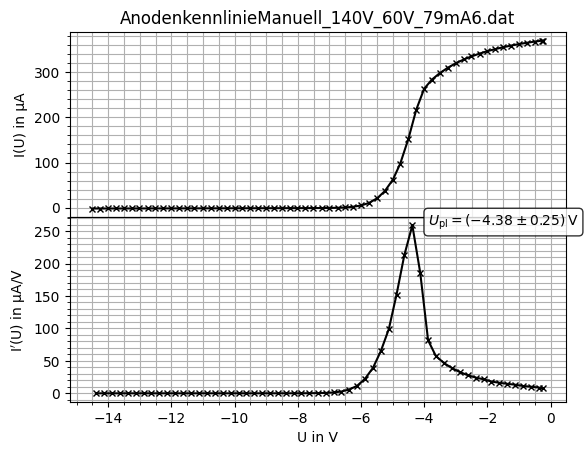

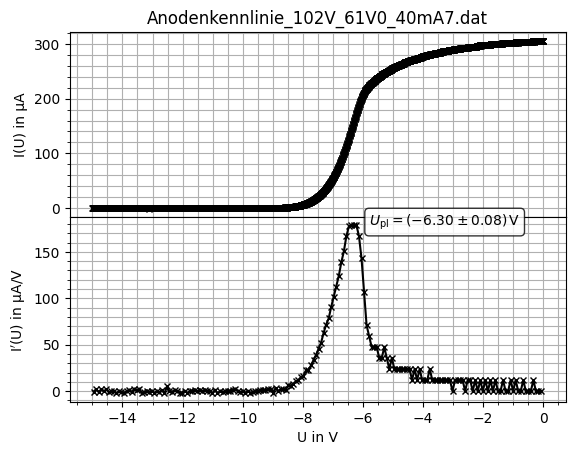

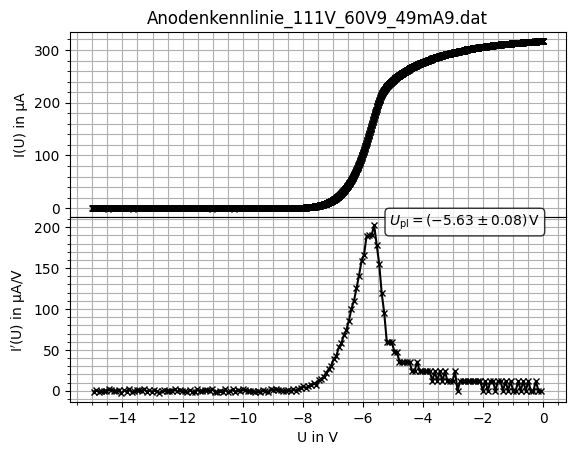

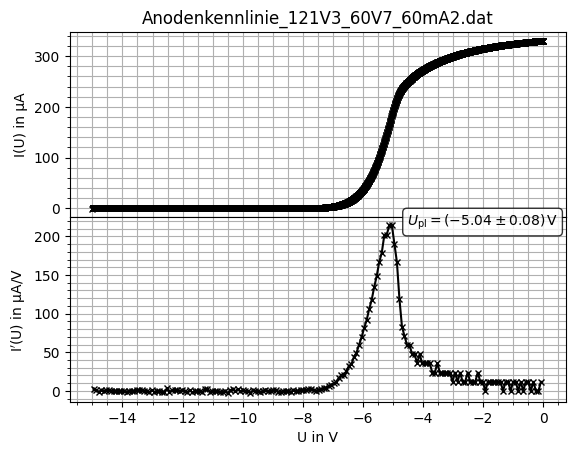

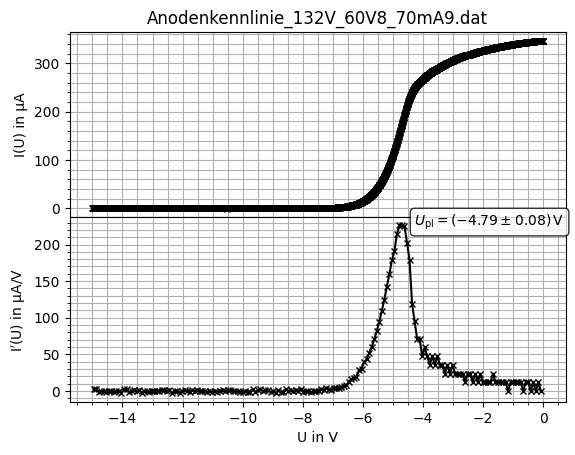

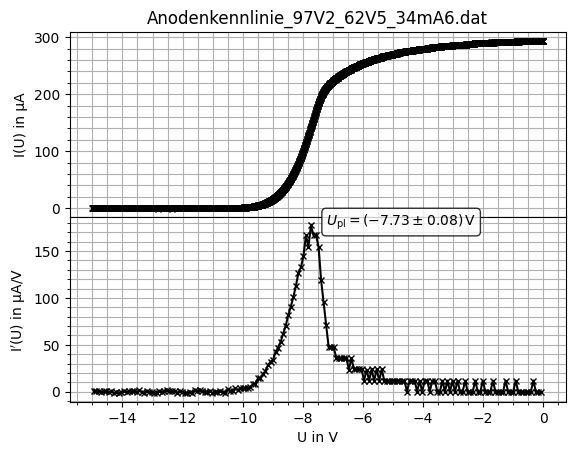

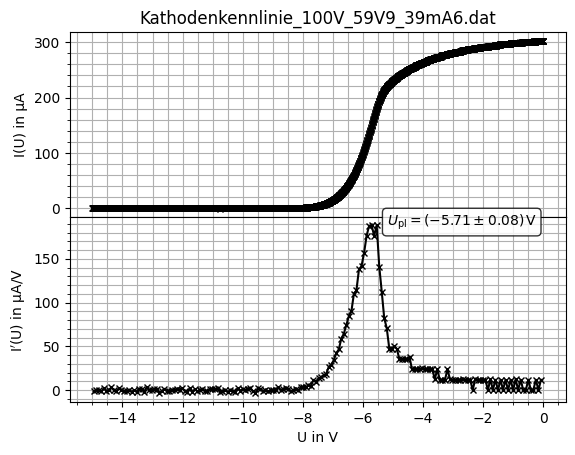

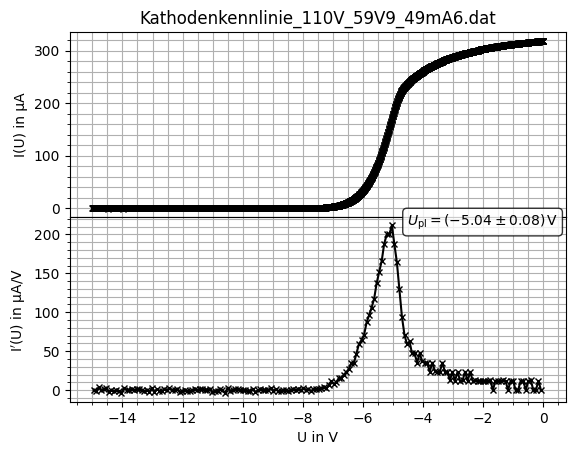

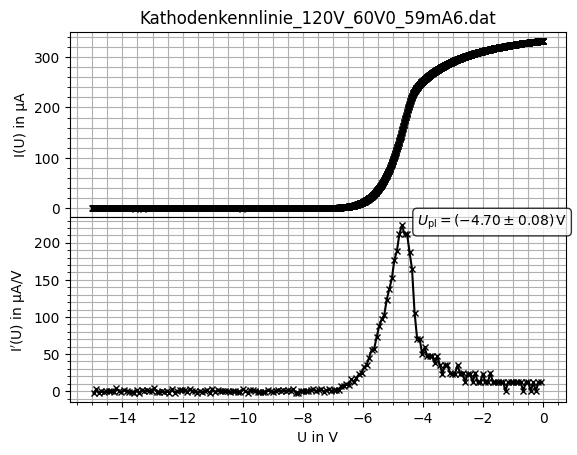

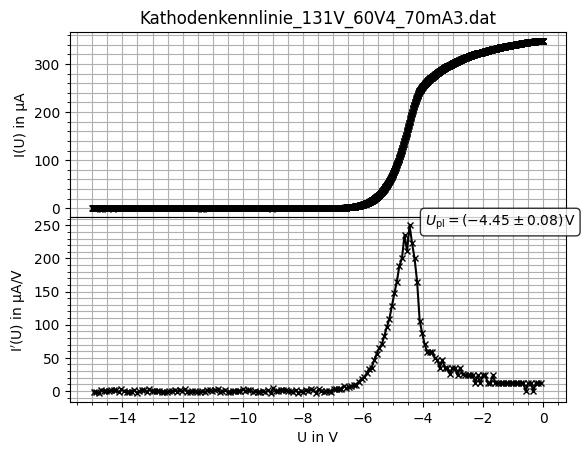

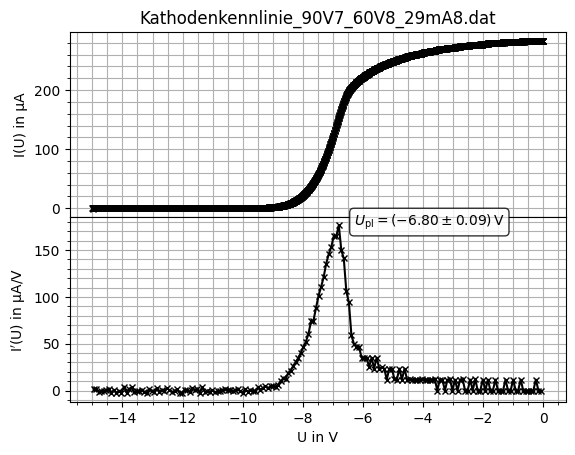

In [66]:
# Methode 1

I_i = {}
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Ableiten der Kennlinie funktioniert für die automatischen mit größeren Steigungsdreiecken
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            (dU, deltaU), dI, dIdU = derive(U, I, step=1)
        else:
            (dU, deltaU), dI, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1 # NaN an index 0 ist sonst max()
        Upl = dU[imaxI]
        Upl_err = deltaU[imaxI]
        # Bestimmen des Ionensättigungsstroms
        I_i_local = I[np.where(I>0)].mean() # bis ersten Nulldurchgang
        I_i[file.split('_')[1]] = I_i_local
        # plotten
        fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, gridspec_kw={'hspace':0.0}) #layout='constrained')
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax2.plot(dU, dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
        ax2.set_xlabel('U in V')
        ax2.set_ylabel(r"I$'$(U) in µA/V")
        ax1.set_ylabel('I(U) in µA')
        ax1.set_title(file)
        ax1.grid(which='both')
        ax2.grid(which='both')
        ax1.minorticks_on()
        ax2.minorticks_on()
        ax2.text(Upl+0.5, dIdU[imaxI], r'$U_\mathrm{pl}= (%4.2f\pm %.2f) \,$V' % (Upl, Upl_err), fontsize=10, bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})
        # optional speichern
        figname = file.split('.')[0]
        plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
        plt.show()

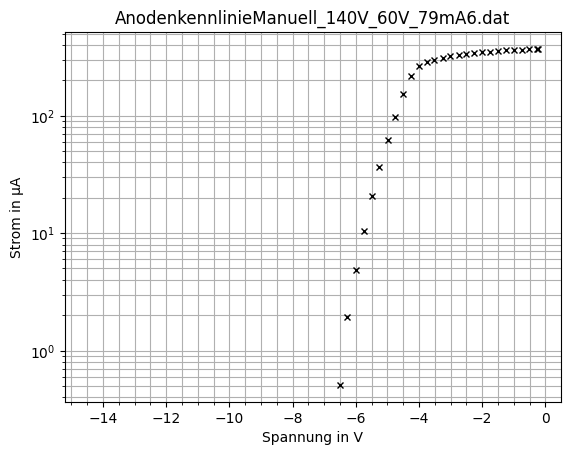

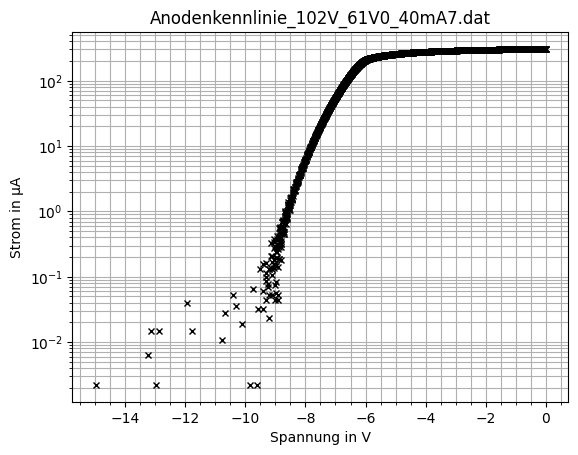

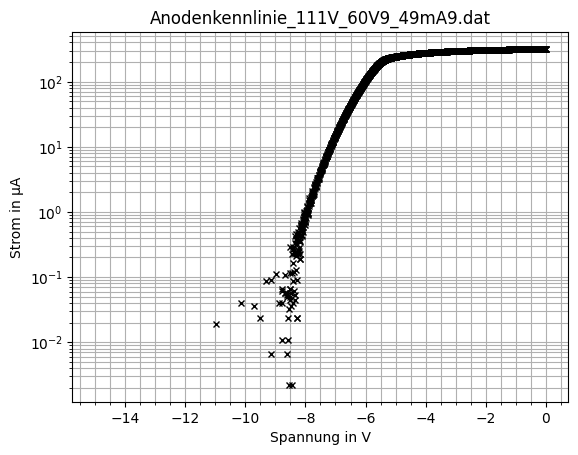

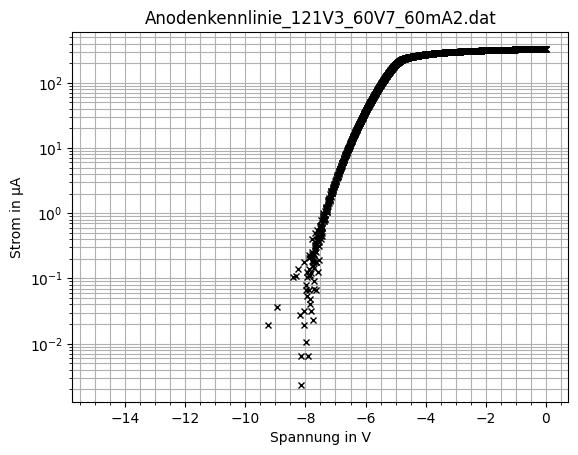

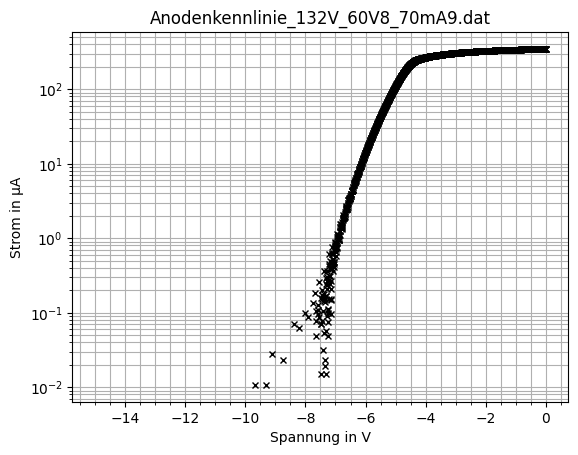

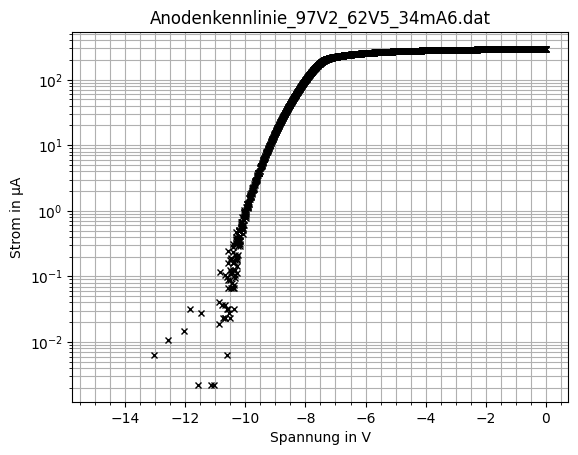

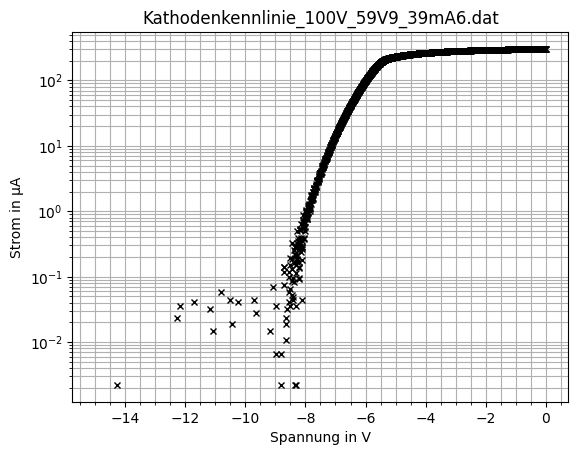

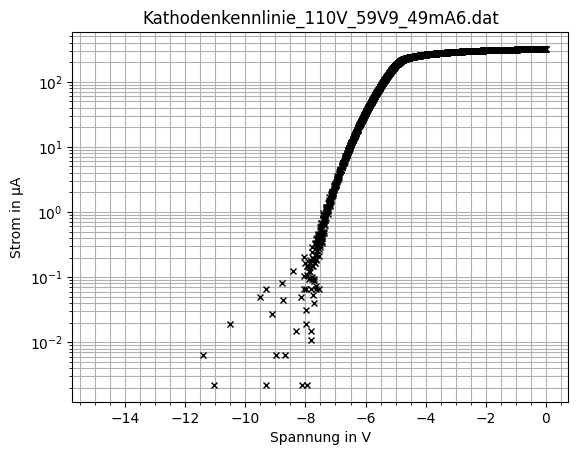

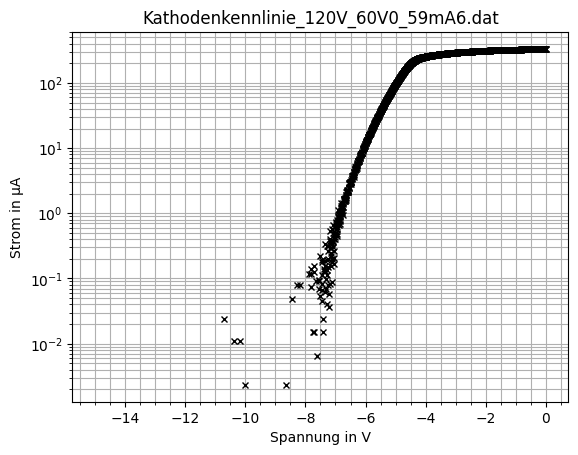

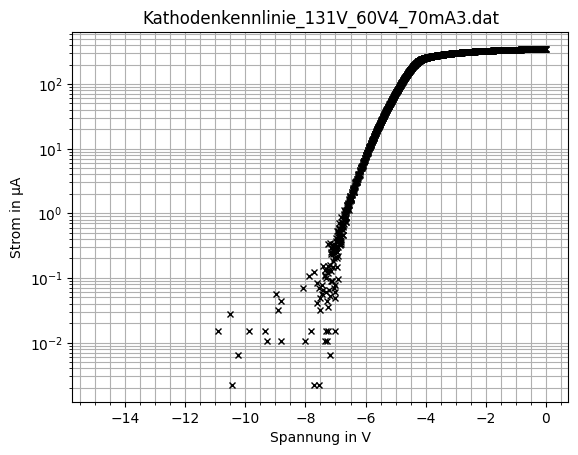

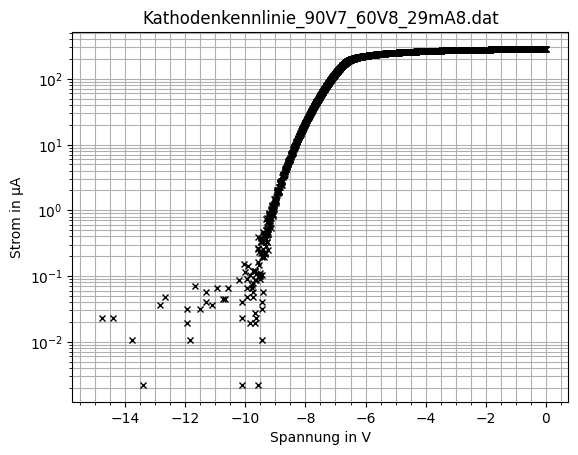

In [4]:
# Methode 2

for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax = plt.subplots()
        ax.plot(U, I, 'xk', ms=4)
        ax.set_xlabel('Spannung in V')
        ax.set_ylabel('Strom in µA')
        ax.set_title(file)
        ax.set_yscale('log')
        ax.minorticks_on()
        plt.grid(which = 'both')
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_logplot.png')
        plt.show()

## Bestimmen des Floating-Potential und Elektronentemperatur
Floating-Potential ist der Nulldurchgang $I(U_\mathrm{float})=0$.  
Für den Elektronstrom im Elektronenanlaufbereich gilt: $$I_\mathrm{e}(U)=-\frac{1}{4}en_eA\sqrt{\frac{8k_BT_e}{\pi m_e}}\exp\left(\frac{e(U-U_{pl})}{k_BT_e} \right).$$

Dies lässt sich umformen zu $$\ln\left(\frac{I_e(U)}{1\,mA}\right)\propto\frac{eU}{k_BT_e}+C.$$
Aus der Steigung im halblogarithmisch geplotteten Elektronenanlaufbereich lässt sich also die Elektronentemperatur bestimmen. Dies sei Methode 1.

Methode 2 ist eine weitere Gleichung $$k_BT_e=\frac{e}{\ln\sqrt{\frac{\exp 1}{2\pi}\frac{m_i}{m_e}}}(U_{pl}-U_{float}).$$

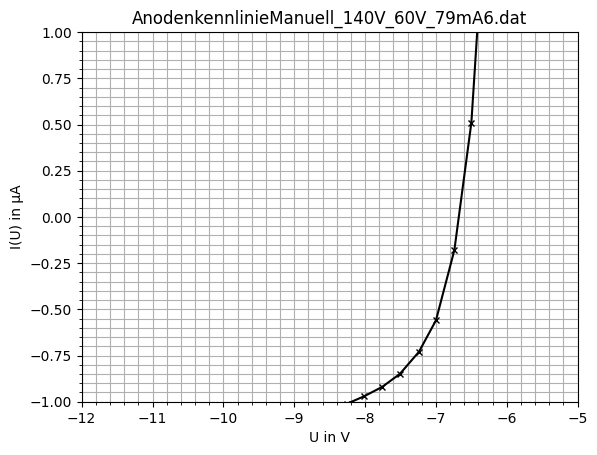

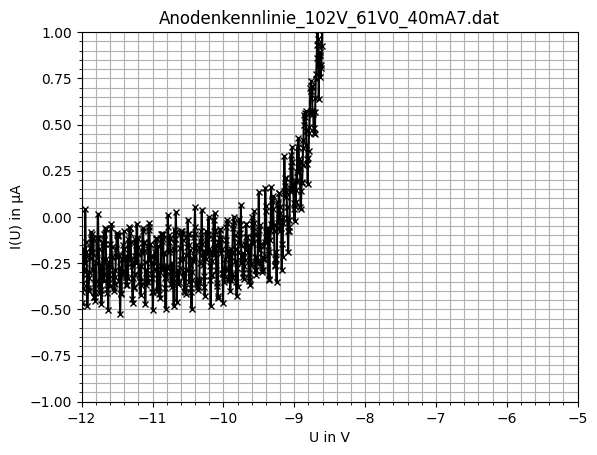

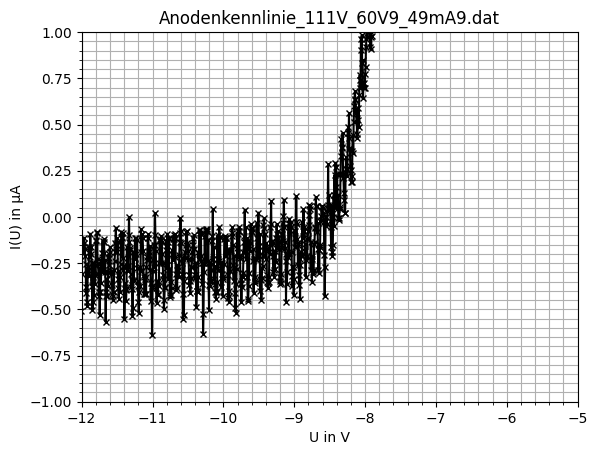

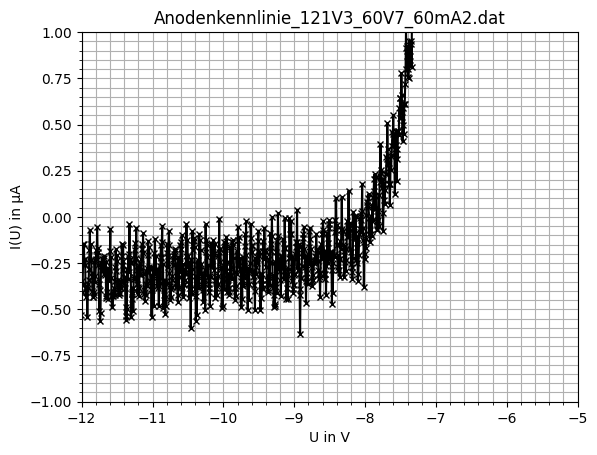

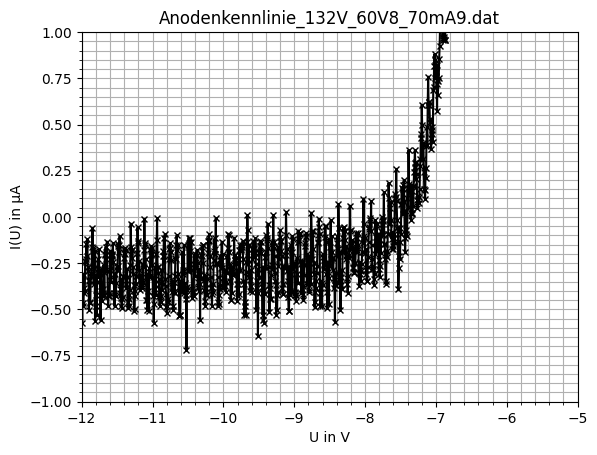

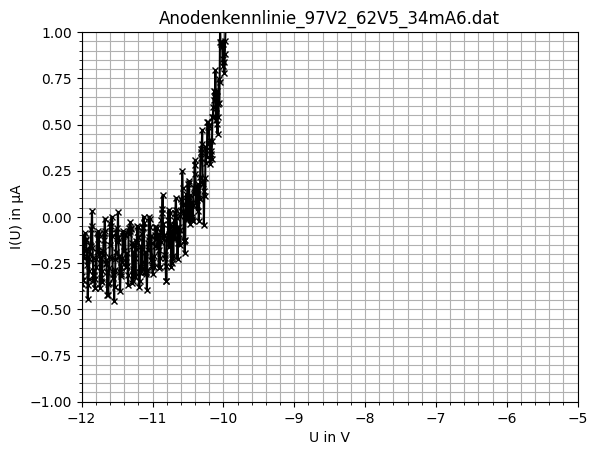

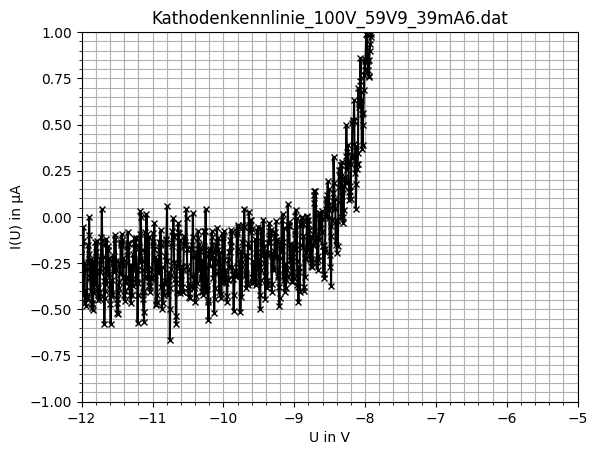

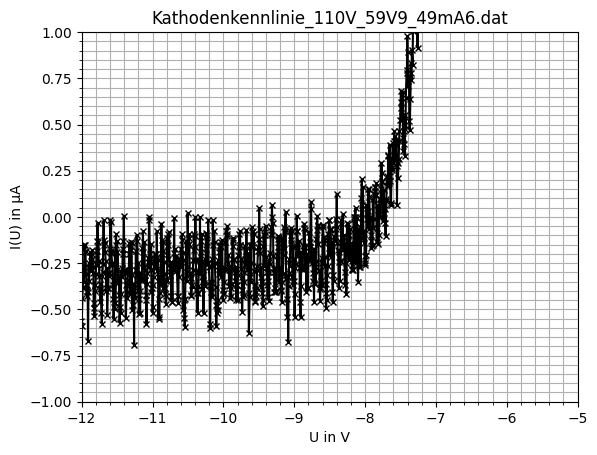

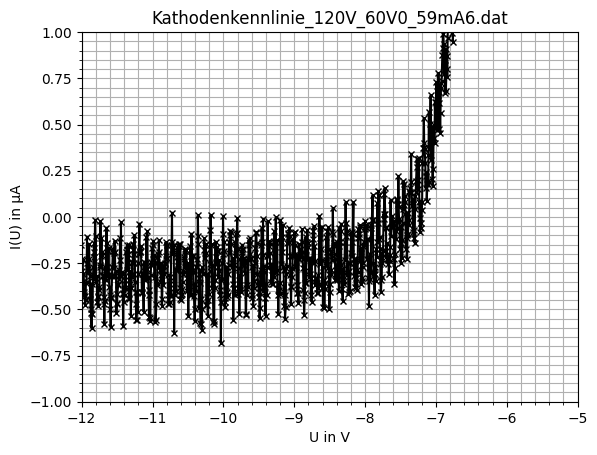

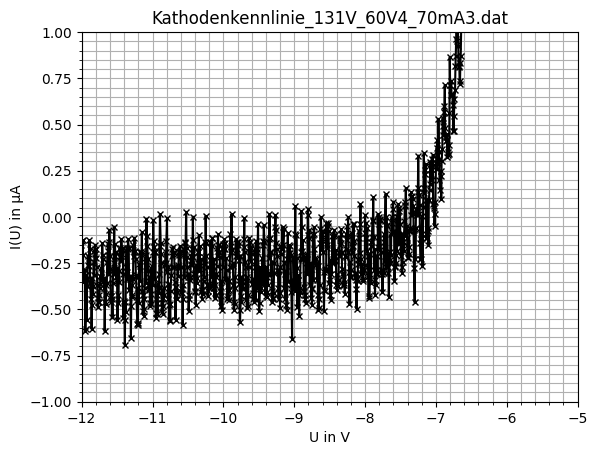

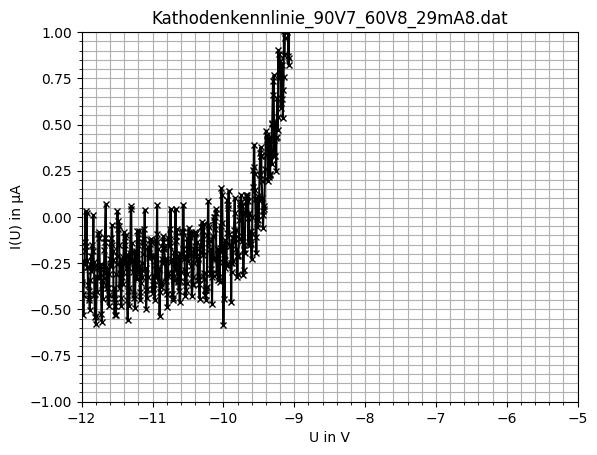

In [5]:
# gezoomte I(U) plots
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax1 = plt.subplots()
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax1.set_xlabel('U in V')
        ax1.set_ylabel('I(U) in µA')
        ax1.set_title(file)
        ax1.grid(which='both')
        ax1.minorticks_on()
        ax1.set_ylim(-1, 1) # reinzoomen um Nulldurchgang abzulesen
        ax1.set_xlim(-12,-5)
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

In [6]:
# Nulldurchgang dict
Ufl = {'140V' : -6.7, # manuelle Kennlinie
       '102V' : -9.2, # Anodenkennlinien
       '111V' : -9.5,
       '121V3': -7.8,
       '132V' : -7.5,
       '97V2' : -10.5,
       '100V' : -8.5,
       '110V' : -7.9,
       '120V' : -7.5,
       '131V' : -7.4,
       '90V7' : -9.6 # Kathodenkennlinien
      } # in V

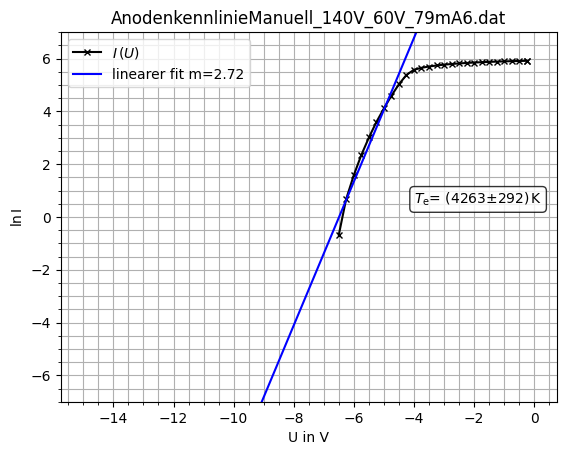

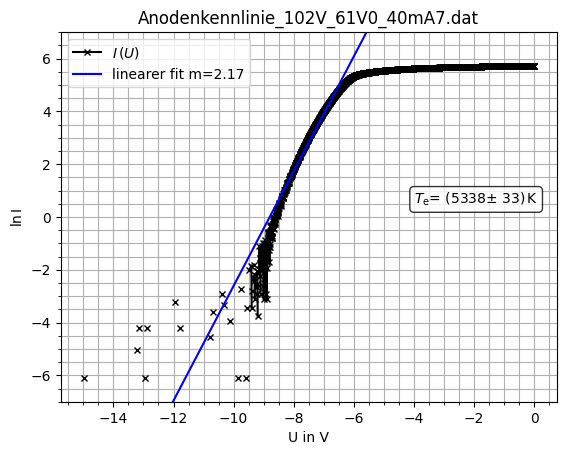

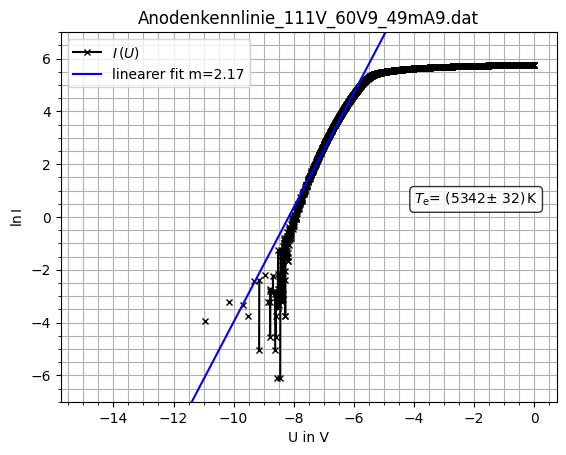

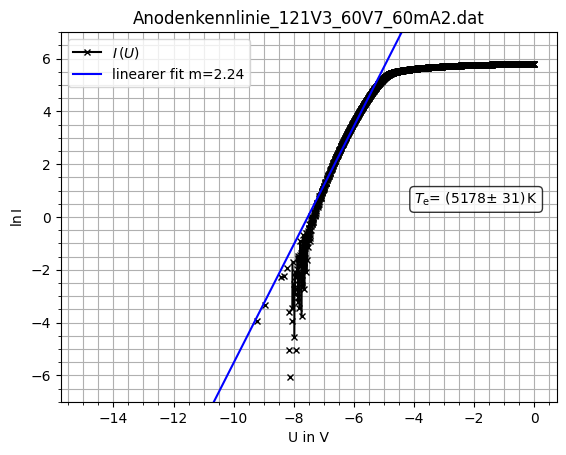

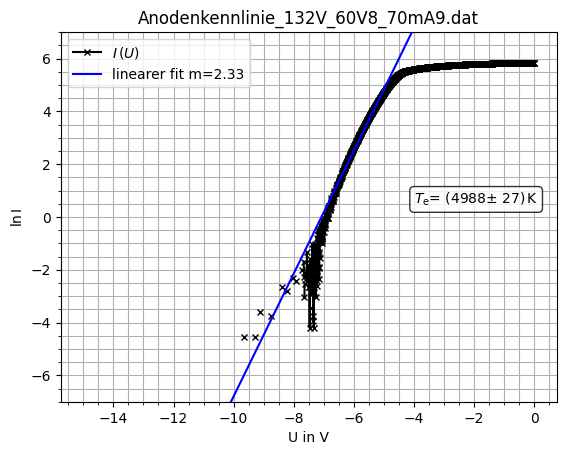

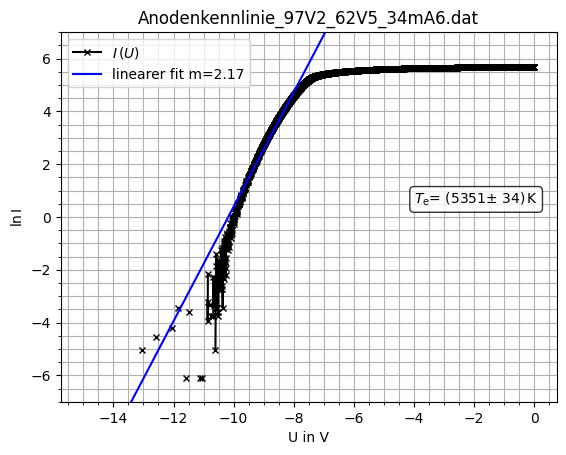

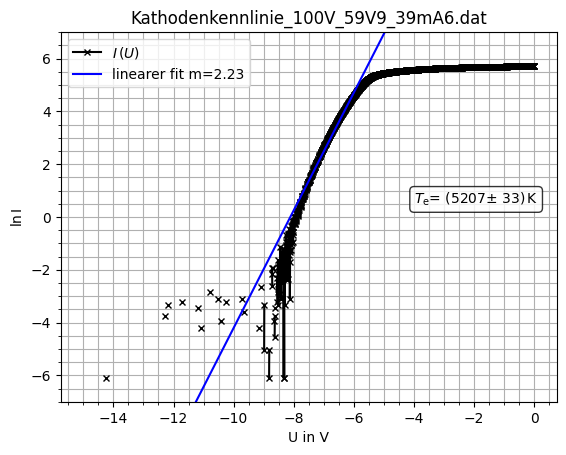

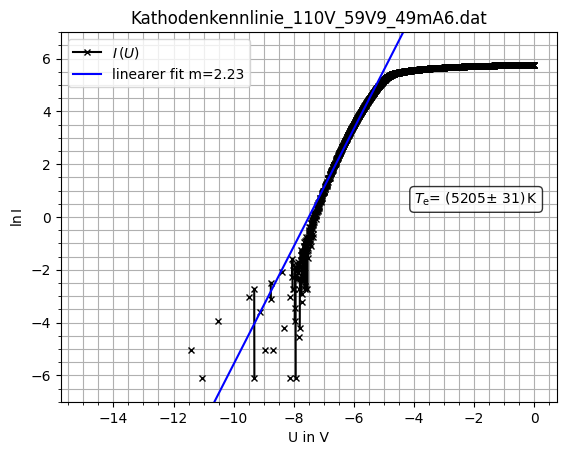

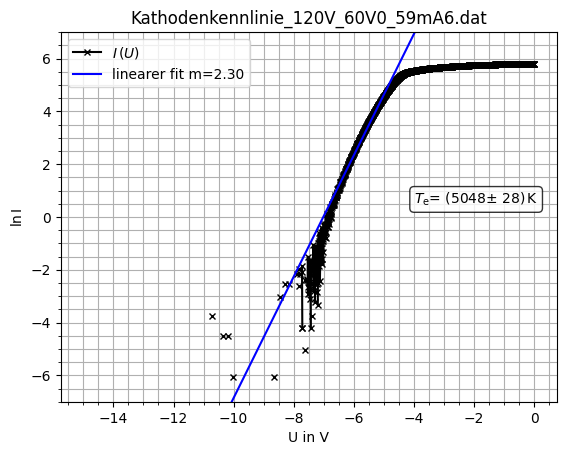

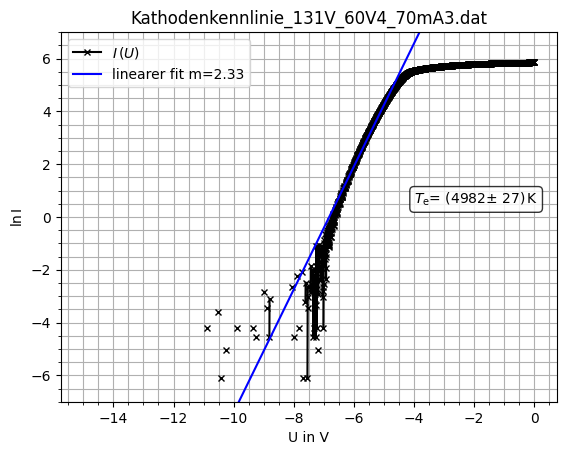

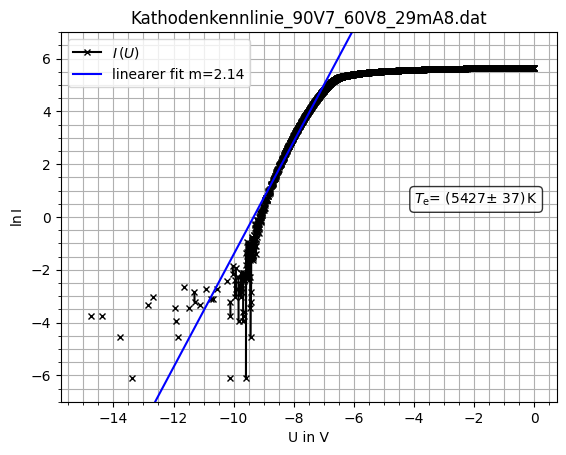

In [16]:
# Methode 1 linear Fit im halb-ln plot
Uplasma = {}
T_e_1 = {}
I_e = {}
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Upl als obere Grenze für Fit bestimmen
        # Ableiten der Kennlinie funktioniert für die automatischen mit größeren Steigungsdreiecken
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU, dI, dIdU = derive(U, I, step=1)
        else:
            dU, dI, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1 # sonst ist nan der max Wert
        Upl = dU[imaxI]
        I_e[file.split('_')[1]] = dI[imaxI]
        Uplasma[file.split('_')[1]]=Upl
        # fitten
        I[np.where(I<0)] = np.nan
        I = np.log(I)
        # Elektronenanlaufbereich isolieren
        lower = max(np.where(I<0))[-1] # Index der niedrigsten Spannung vor der ersten 0
        upper = max(np.where(U<Upl))[-1] # Index der höchsten Spannung < Uplasma
        I_eanlauf = I[lower:upper+1]
        U_eanlauf = U[lower:upper+1]
        ## lm least squares
        #init = [1,0]
        #fit = least_squares(linear_res, init, args=(U_eanlauf, I_eanlauf), method='lm')
        #T_e_local = const.e/fit.x[0]/const.k
        ## linregress fit
        fit = linregress(U_eanlauf, I_eanlauf)
        T_e_local = const.e/fit.slope/const.k
        T_e_err = abs(T_e_local/fit.slope)*fit.stderr
        T_e_1[file.split('_')[1]] = (T_e_local, T_e_err)
        # plotten
        fig, ax = plt.subplots()
        ax.plot(U, I, 'x-k', ms=4, label=r'$I\,(U)$')
        ax.plot(U, linear((fit.slope, fit.intercept), U), 'b', label=f'linearer fit m={fit.slope:4.2f}')
        ax.set_xlabel('U in V')
        ax.set_ylabel(r'$\ln$I')
        ax.set_title(file)
        ax.legend(loc=2)
        ax.grid(which='both')
        ax.minorticks_on()
        ax.set_ylim(-7, 7)
        ax.set_xlim(-15.75, 0.75)
        ax.text(-4, 0.5, r'$T_\mathrm{e}$= (' + f'{T_e_local:4.0f}' + r'$\pm$' + f'{T_e_err:3.0f}' + r'$)\,$K', fontsize=10, bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

In [19]:
# Methode 2
def T_e(Upl, Ufl):
    return const.e/np.log(np.sqrt(np.exp(1)/(2*np.pi)*(40*const.m_p)/(const.m_e)))*(Upl-Ufl)/const.k

print(f"Sind die Spannungs-Dictionaries in gleicher Reihenfolge? {Uplasma.keys()==Ufl.keys()}")

methode2 = []
for Up, Uf in zip(Uplasma.values(), Ufl.values()):
    methode2.append(T_e(Up, Uf))

for kennlinie, entry in zip(Ufl.keys(), methode2):
    print(f'Te von "{kennlinie}" = {entry:4.0f} K')

Sind die Spannungs-Dictionaries in gleicher Reihenfolge? True
Te von "140V" = 5205 K
Te von "102V" = 6494 K
Te von "111V" = 8671 K
Te von "121V3" = 6183 K
Te von "132V" = 6075 K
Te von "97V2" = 6204 K
Te von "100V" = 6241 K
Te von "110V" = 6409 K
Te von "120V" = 6263 K
Te von "131V" = 6605 K
Te von "90V7" = 6263 K


## Bestimmen der Plasmadichte
Zum Bestimmen der Plasmadichte verwenden wir die Formel $$I_e(U_{pl})=-\frac14en_eA\sqrt{\frac{8k_BT_e}{\pi m_e}}\cdot1,$$ wobei die Fläche A aus der Tabelle in der Anleitung als $A=8.9(9)\mathrm{mm}^2$ abzulesen ist.

In [ ]:
# Elektronendichte
def n_e(I_e, T_e):
    A = 8.9e-6 # Sondenfläche in qm
    return 4*I_e/const.e/A*np.sqrt(np.pi*const.m_e/(8*const.k*T_e)) # - weg weil Vorzeichen von e? idk
def n_e_err(n_e, T_e, T_e_err):
    return abs(0.5/T_e*n_e)*T_e_err

n_e_1 = {} # Elekteronendichte aus Elektronenetemperatur Methode 1
n_e_2 = {}
print("Für T_e aus Methode 1:")
for kennlinie, (T_e, T_e_err), I_elek in zip(Ufl.keys(), T_e_1.values(), I_e.values()):
    n = n_e(I_elek*1e-6, T_e)
    n_err = n_e_err(n, T_e, T_e_err)
    n_e_1[kennlinie] = (n, n_err)
    print('n_e von "{}" = ({:.0f} +/- {:.0f})e+12 1/m^3'.format(kennlinie, n/1e12, n_err/1e12))

print("\nFür T_e aus Methode 2:")
for kennlinie, T_e, I_elek in zip(Ufl.keys(), methode2, I_e.values()):
    n = n_e(I_elek*1e-6, T_e
    n_e_2[kennlinie] = )
    print(f'n_e von "{kennlinie}" = {n_e(I_elek*1e-6, T_e):.2e} 1/m^3')

Für T_e aus Methode 1:
n_e von "140V" = (1501 +/- 51)e+12 1/m^3
n_e von "102V" = (1020 +/- 3)e+12 1/m^3
n_e von "111V" = (1124 +/- 3)e+12 1/m^3
n_e von "121V3" = (1205 +/- 4)e+12 1/m^3
n_e von "132V" = (1048 +/- 3)e+12 1/m^3
n_e von "97V2" = (920 +/- 3)e+12 1/m^3
n_e von "100V" = (982 +/- 3)e+12 1/m^3
n_e von "110V" = (1120 +/- 3)e+12 1/m^3
n_e von "120V" = (1036 +/- 3)e+12 1/m^3
n_e von "131V" = (1209 +/- 3)e+12 1/m^3
n_e von "90V7" = (987 +/- 3)e+12 1/m^3

Für T_e aus Methode 2:
n_e von "140V" = 1.36e+15 1/m^3
n_e von "102V" = 9.25e+14 1/m^3
n_e von "111V" = 8.83e+14 1/m^3
n_e von "121V3" = 1.10e+15 1/m^3
n_e von "132V" = 9.50e+14 1/m^3
n_e von "97V2" = 8.54e+14 1/m^3
n_e von "100V" = 8.97e+14 1/m^3
n_e von "110V" = 1.01e+15 1/m^3
n_e von "120V" = 9.30e+14 1/m^3
n_e von "131V" = 1.05e+15 1/m^3
n_e von "90V7" = 9.19e+14 1/m^3


Die Ionendichte $n_i$ lässt sich mittels Formel (9) aus der Anleitung bestimmen
$$I_i=0.6en_iA\sqrt{\frac{k_BT_e}{m_i}}.$$

In [ ]:
def n_i(I_i, T_e):
    A = 8.9e-6 # Sondenfläche in qm
    return I_i/(0.6*const.e*A)*np.sqrt(40*const.m_p/(const.k*T_e))

print("Für T_e aus Methode 1:")
for kennlinie, T_e, I_ion in zip(Ufl.keys(), T_e_1.values(), I_i.values()):
    print(f'n_i von "{kennlinie}" = {n_e(I_ion*1e-6, T_e):.2e} 1/m^3')

print("\nFür T_e aus Methode 2:")
for kennlinie, T_e, I_ion in zip(Ufl.keys(), methode2, I_i.values()):
    print(f'n_i von "{kennlinie}" = {n_e(I_ion*1e-6, T_e):.2e} 1/m^3')

Für T_e aus Methode 1:
n_i von "140V" = 1.62e+15 1/m^3
n_i von "102V" = 1.22e+15 1/m^3
n_i von "111V" = 1.23e+15 1/m^3
n_i von "121V3" = 1.26e+15 1/m^3
n_i von "132V" = 1.30e+15 1/m^3
n_i von "97V2" = 1.25e+15 1/m^3
n_i von "100V" = 1.18e+15 1/m^3
n_i von "110V" = 1.20e+15 1/m^3
n_i von "120V" = 1.24e+15 1/m^3
n_i von "131V" = 1.27e+15 1/m^3
n_i von "90V7" = 1.16e+15 1/m^3

Für T_e aus Methode 2:
n_i von "140V" = 1.47e+15 1/m^3
n_i von "102V" = 1.11e+15 1/m^3
n_i von "111V" = 9.65e+14 1/m^3
n_i von "121V3" = 1.16e+15 1/m^3
n_i von "132V" = 1.18e+15 1/m^3
n_i von "97V2" = 1.16e+15 1/m^3
n_i von "100V" = 1.08e+15 1/m^3
n_i von "110V" = 1.08e+15 1/m^3
n_i von "120V" = 1.11e+15 1/m^3
n_i von "131V" = 1.10e+15 1/m^3
n_i von "90V7" = 1.08e+15 1/m^3


## Ionisierungsgrad, Debye-Länge und Plasmafrequenz
Formel für Ioniesierungsgrad: $x=\frac{n_ek_BT}{p}$, wobei $p=100\,\mathrm{Pa}$ und $T=300\,\mathrm{K}$.  
Formel für Debye-Länge: $\lambda_\mathrm{D}=\sqrt{\frac{\epsilon_0k_BT_e}{n_ee^2}}$  
Formel für Plasmafrequenz: $\omega_\mathrm{P}=\sqrt{\frac{n_ee^2}{\epsilon_0m_e}}$

In [ ]:
# Ionisierungsgrad
def x(n_e):
    T = 300
    p = 100
    return n_e*const.k*T/p

# Debyelänge
def Debye(n_e, T_e):
    return np.sqrt(const.epsilon_0*const.k*T_e/n_e/const.e**2)

#Plasmafrequenz
def PFreq(n_e):
    return np.sqrt(n_e*const.e**2/const.epsilon_0/const.m_e)

In [ ]:
print('T_e via Methode 1:')
for ident, n, T in zip(n_e_1.keys(), n_e_1.values(), T_e_1.values()):
    print(f'Für "{ident}": x= {x(n):.2e}, l= {Debye(n, T):.2e} m, w= {PFreq(n):.2e} 1/s')

print('\nT_e via Methode 2:')
for ident, n, T in zip(n_e_2.keys(), n_e_2.values(), methode2):
    print(f'Für "{ident}": x= {x(n):.2e}, l= {Debye(n, T):.2e} m, w= {PFreq(n):.2e} 1/s')

T_e via Methode 1:
Für "140V": x= 6.22e-08, l= 1.16e-04 m, w= 2.19e+09 1/s
Für "102V": x= 4.22e-08, l= 1.58e-04 m, w= 1.80e+09 1/s
Für "111V": x= 4.66e-08, l= 1.50e-04 m, w= 1.89e+09 1/s
Für "121V3": x= 4.99e-08, l= 1.43e-04 m, w= 1.96e+09 1/s
Für "132V": x= 4.34e-08, l= 1.51e-04 m, w= 1.83e+09 1/s
Für "97V2": x= 3.81e-08, l= 1.66e-04 m, w= 1.71e+09 1/s
Für "100V": x= 4.07e-08, l= 1.59e-04 m, w= 1.77e+09 1/s
Für "110V": x= 4.64e-08, l= 1.49e-04 m, w= 1.89e+09 1/s
Für "120V": x= 4.29e-08, l= 1.52e-04 m, w= 1.82e+09 1/s
Für "131V": x= 5.01e-08, l= 1.40e-04 m, w= 1.96e+09 1/s
Für "90V7": x= 4.09e-08, l= 1.62e-04 m, w= 1.77e+09 1/s

T_e via Methode 2:
Für "140V": x= 5.63e-08, l= 1.35e-04 m, w= 2.08e+09 1/s
Für "102V": x= 3.83e-08, l= 1.83e-04 m, w= 1.72e+09 1/s
Für "111V": x= 3.66e-08, l= 2.16e-04 m, w= 1.68e+09 1/s
Für "121V3": x= 4.57e-08, l= 1.63e-04 m, w= 1.87e+09 1/s
Für "132V": x= 3.94e-08, l= 1.75e-04 m, w= 1.74e+09 1/s
Für "97V2": x= 3.54e-08, l= 1.86e-04 m, w= 1.65e+09 1/s
Für "10

## Druyvesteyn Methode

zweite Ableitung der manuellen Kennlinie zur Berechnung der Geschwindigkeitsverteilung

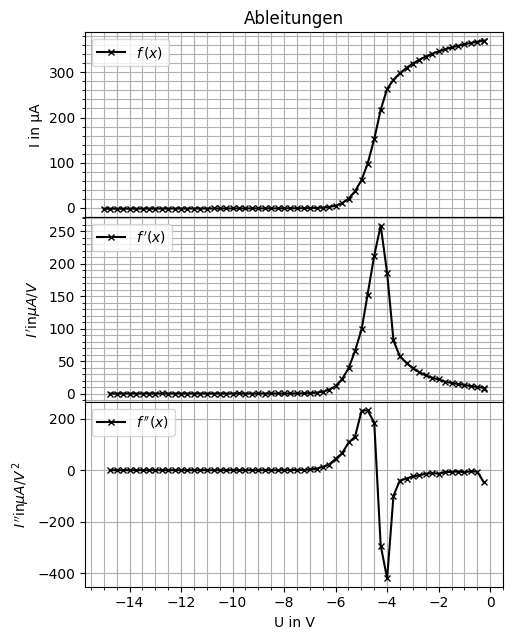

In [ ]:
manlinie = np.loadtxt('../Messdaten/17112025_Langmuirsonden/AnodenkennlinieManuell_140V_60V_79mA6.dat', delimiter='\t', skiprows=1)

U = manlinie[:,0]
I = manlinie[:,1]*1e6 #in µA

dIdU = np.diff(I)/np.diff(U)
d2IdU2 = np.diff(dIdU)/np.diff(U[1:])


# plotten
fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,7.2)) #layout='constrained')
ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
ax2.plot(U[1:], dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
ax3.plot(U[1:-1], d2IdU2, 'x-k', ms=4, label=r"$f\,^{\prime\prime} (x)$")
ax3.set_xlabel('U in V')
ax1.set_ylabel('I in µA')
ax2.set_ylabel(r'$I\,^\prime \mathrm{ in } µA/V$')
ax3.set_ylabel(r'$I\,^{\prime\prime} \mathrm{ in } µA/V\,^2$')
ax1.set_title('Ableitungen')
ax1.legend(loc=2)
ax1.grid(which='both')
ax2.legend(loc=2)
ax2.grid(which='both')
ax3.legend(loc=2)
ax3.grid(which='both')
ax1.minorticks_on()
ax2.minorticks_on()
ax2.minorticks_on()
        # optional speichern
figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
plt.show()

Berechnung der Geschwindigkeitsverteilung 
mit $m_e^2/(e^3 2\pi A) = 3.6081\pm0.3649$
für $A = (8.9\pm0.9)mm^2$
und $2e/m_e = 3.51764e11$
und $U_pl = -4.25V$

In [ ]:
f = -3.6081*d2IdU2 

mask = np.where(U<-4.25)
v = np.sqrt(3.51764e11*(-4.25-U[mask]))



print(f'Mittlere Energie der Elektronen: {((0.5*const.m_e*v**2+const.m_e*const.c**2)/const.e/1e6).mean()} MeV')

Mittlere Energie der Elektronen: 0.5110044520870759 MeV
